In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd, norm
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from numba import njit


# -------------------------
# Parameters
# -------------------------
N_side = 20
N = N_side**2
T = 2
M_side = int(np.sqrt(T * N))
M = M_side**2
c = 1/20
b = c * N
#mu = 2.5e4
#rho = 250.0

mu = 2.5e4
rho = 1e5

max_iter = 10_000
tau = 1e-15
tol = 5e-7
L = 1.0

# -------------------------
# Domain
# -------------------------
x = np.linspace(0, L, M_side)
X, Y = np.meshgrid(x, x)
collocation_pts = np.column_stack((X.ravel(), Y.ravel()))

cx = np.linspace(0, L, N_side)
CY, CX = np.meshgrid(cx, cx)
centers = np.column_stack((CX.ravel(), CY.ravel()))

# -------------------------
# Obstacle and solution
# -------------------------
def psi(xy): return np.sin(np.pi * xy[:, 0]) * np.sin(np.pi * xy[:, 1])

# ------------------------------------------------------------------
#  Dirichlet boundary data  g(θ)  – a sine curve around the rim
# ------------------------------------------------------------------
# amplitude and frequency knobs
A = 0.1 # height of the sine lobes
k = 6   # one full oscillation along each edge (2pi phase)
pi = np.pi
sinh_kpi = np.sinh(k*pi)

def psi(xy, height = 2.0):
    x, y = xy[:,0], xy[:,1]
    return height*np.sin(pi*x) * np.sin(pi*y)

def H(xy):
    x, y = xy[:,0], xy[:,1]
    term_x = np.sin(k*pi*x)*(np.sinh(k*pi*y)+np.sinh(k*pi*(1-y)))/sinh_kpi
    term_y = np.sin(k*pi*y)*(np.sinh(k*pi*x)+np.sinh(k*pi*(1-x)))/sinh_kpi
    return A*(term_x + term_y)

def g_boundary_square(pts, L=1.0, A=A, k=k):
    """
    Vectorised Dirichlet data on the square boundary.

    pts : (n_bc,2) array of boundary points.
    L   : domain length (1.0 for the unit square).
    """
    x = pts[:, 0]
    y = pts[:, 1]
    g = np.zeros_like(x)

    # bottom (y≈0) and top (y≈L) edges
    mask_bottom = np.isclose(y, 0.0)
    mask_top    = np.isclose(y, L)
    g[mask_bottom] = A * np.sin(k * np.pi * x[mask_bottom] / L)
    g[mask_top]    = A * np.sin(k * np.pi * x[mask_top]    / L)

    # left (x≈0) and right (x≈L) edges
    mask_left  = np.isclose(x, 0.0)
    mask_right = np.isclose(x, L)
    g[mask_left]  = A * np.sin(k * np.pi * y[mask_left]  / L)
    g[mask_right] = A * np.sin(k * np.pi * y[mask_right] / L)

    return g


#def analytical_u(xy): return np.maximum(0, psi(xy))

def u_true(xy):
    return np.maximum(psi(xy), H(xy))

#psi_vals = psi_rescaled(collocation_pts)
#u_exact_vals = u_true_rescaled(collocation_pts)

psi_vals = psi(collocation_pts)
u_exact_vals = u_true(collocation_pts)


# -------------------------
# Numba-accelerated RBF
# -------------------------
@njit
def rbf_fast(xy, centers, b):
    M, N = xy.shape[0], centers.shape[0]
    out = np.empty((M, N))
    for i in range(M):
        for j in range(N):
            dx = xy[i, 0] - centers[j, 0]
            dy = xy[i, 1] - centers[j, 1]
            r2 = dx * dx + dy * dy
            out[i, j] = np.exp(-b * b * r2)
    return out

Phi_raw = rbf_fast(collocation_pts, centers, b)
Phi = Phi_raw / np.sqrt(N)
dx = L / (M_side - 1)
A1 = dx**2 * Phi.T @ Phi

# -------------------------
# Boundary
# -------------------------
boundary_mask = (np.isclose(collocation_pts[:, 0], 0) |
                 np.isclose(collocation_pts[:, 0], L) |
                 np.isclose(collocation_pts[:, 1], 0) |
                 np.isclose(collocation_pts[:, 1], L))


Phi_bc = Phi[boundary_mask, :]
#zero_bc = np.zeros(np.sum(boundary_mask))
g_bc   = g_boundary_square(collocation_pts[boundary_mask], L=L)   # NEW



beta = 3e5
A = A1 + beta * (Phi_bc.T @ Phi_bc)
lhs = A + rho * (Phi.T @ Phi)

# -------------------------
# TSVD Solver
# -------------------------
U, S, VT = svd(lhs, full_matrices=False)
svd_tol = tau * np.max(S)
S_inv = np.where(S > svd_tol, 1 / S, 0)
def svd_solve(U, S_inv, VT, b): return VT.T @ (S_inv * (U.T @ b))

# -------------------------
# ADMM initialization
# -------------------------
w = np.zeros(N)
v = Phi @ w
z = np.zeros(M)
primal_residuals, dual_residuals = [], []

# -------------------------
# ADMM iteration
# -------------------------
for it in range(max_iter):
    #rhs = rho * Phi.T @ (v - z) + beta * (Phi_bc.T @ zero_bc) # zero boundary condition to check.
    rhs = rho * Phi.T @ (v - z) + beta * (Phi_bc.T @ g_bc)
    w_new = svd_solve(U, S_inv, VT, rhs)
    ratio = mu * dx**2 / rho
    w_proj = Phi @ w_new + z
    v_new = np.maximum(w_proj - ratio, psi_vals)
    z_new = z + (Phi @ w_new - v_new)

    r_k = Phi @ w_new - v_new
    s_k = rho * Phi.T @ (v_new - v)

    norm_u = norm(Phi @ w_new)
    norm_v = norm(v_new)
    primal_res = norm(r_k) / max(norm_u, norm_v, tol)
    dual_res = norm(s_k) / max(norm(rho * Phi.T @ z), tol)

    primal_residuals.append(primal_res)
    dual_residuals.append(dual_res)

    if (it % 500 == 0) or (primal_res < tol and dual_res < tol):
        print(f"Iter {it}: Primal Residual = {primal_res:.2e}, Dual Residual = {dual_res:.2e}")
    if primal_res < tol and dual_res < tol:
        print(f"Converged at iteration {it}")
        break

    w, v, z = w_new, v_new, z_new

# -------------------------
# Post-processing
# -------------------------
u_rbf = Phi @ w
U_rbf = u_rbf.reshape(M_side, M_side)
U_exact = u_exact_vals.reshape(M_side, M_side)
Psi = psi_vals.reshape(M_side, M_side)
abs_error = np.abs(U_rbf - U_exact)


Iter 0: Primal Residual = 1.00e+00, Dual Residual = 1.08e+12
Iter 500: Primal Residual = 2.27e-07, Dual Residual = 3.36e-06
Iter 1000: Primal Residual = 7.10e-08, Dual Residual = 3.06e-06
Iter 1445: Primal Residual = 1.95e-07, Dual Residual = 4.96e-07
Converged at iteration 1445


Grid Size: m x m: 784x784
Relative L2 error (RBF vs Analytical): 5.07e-05


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

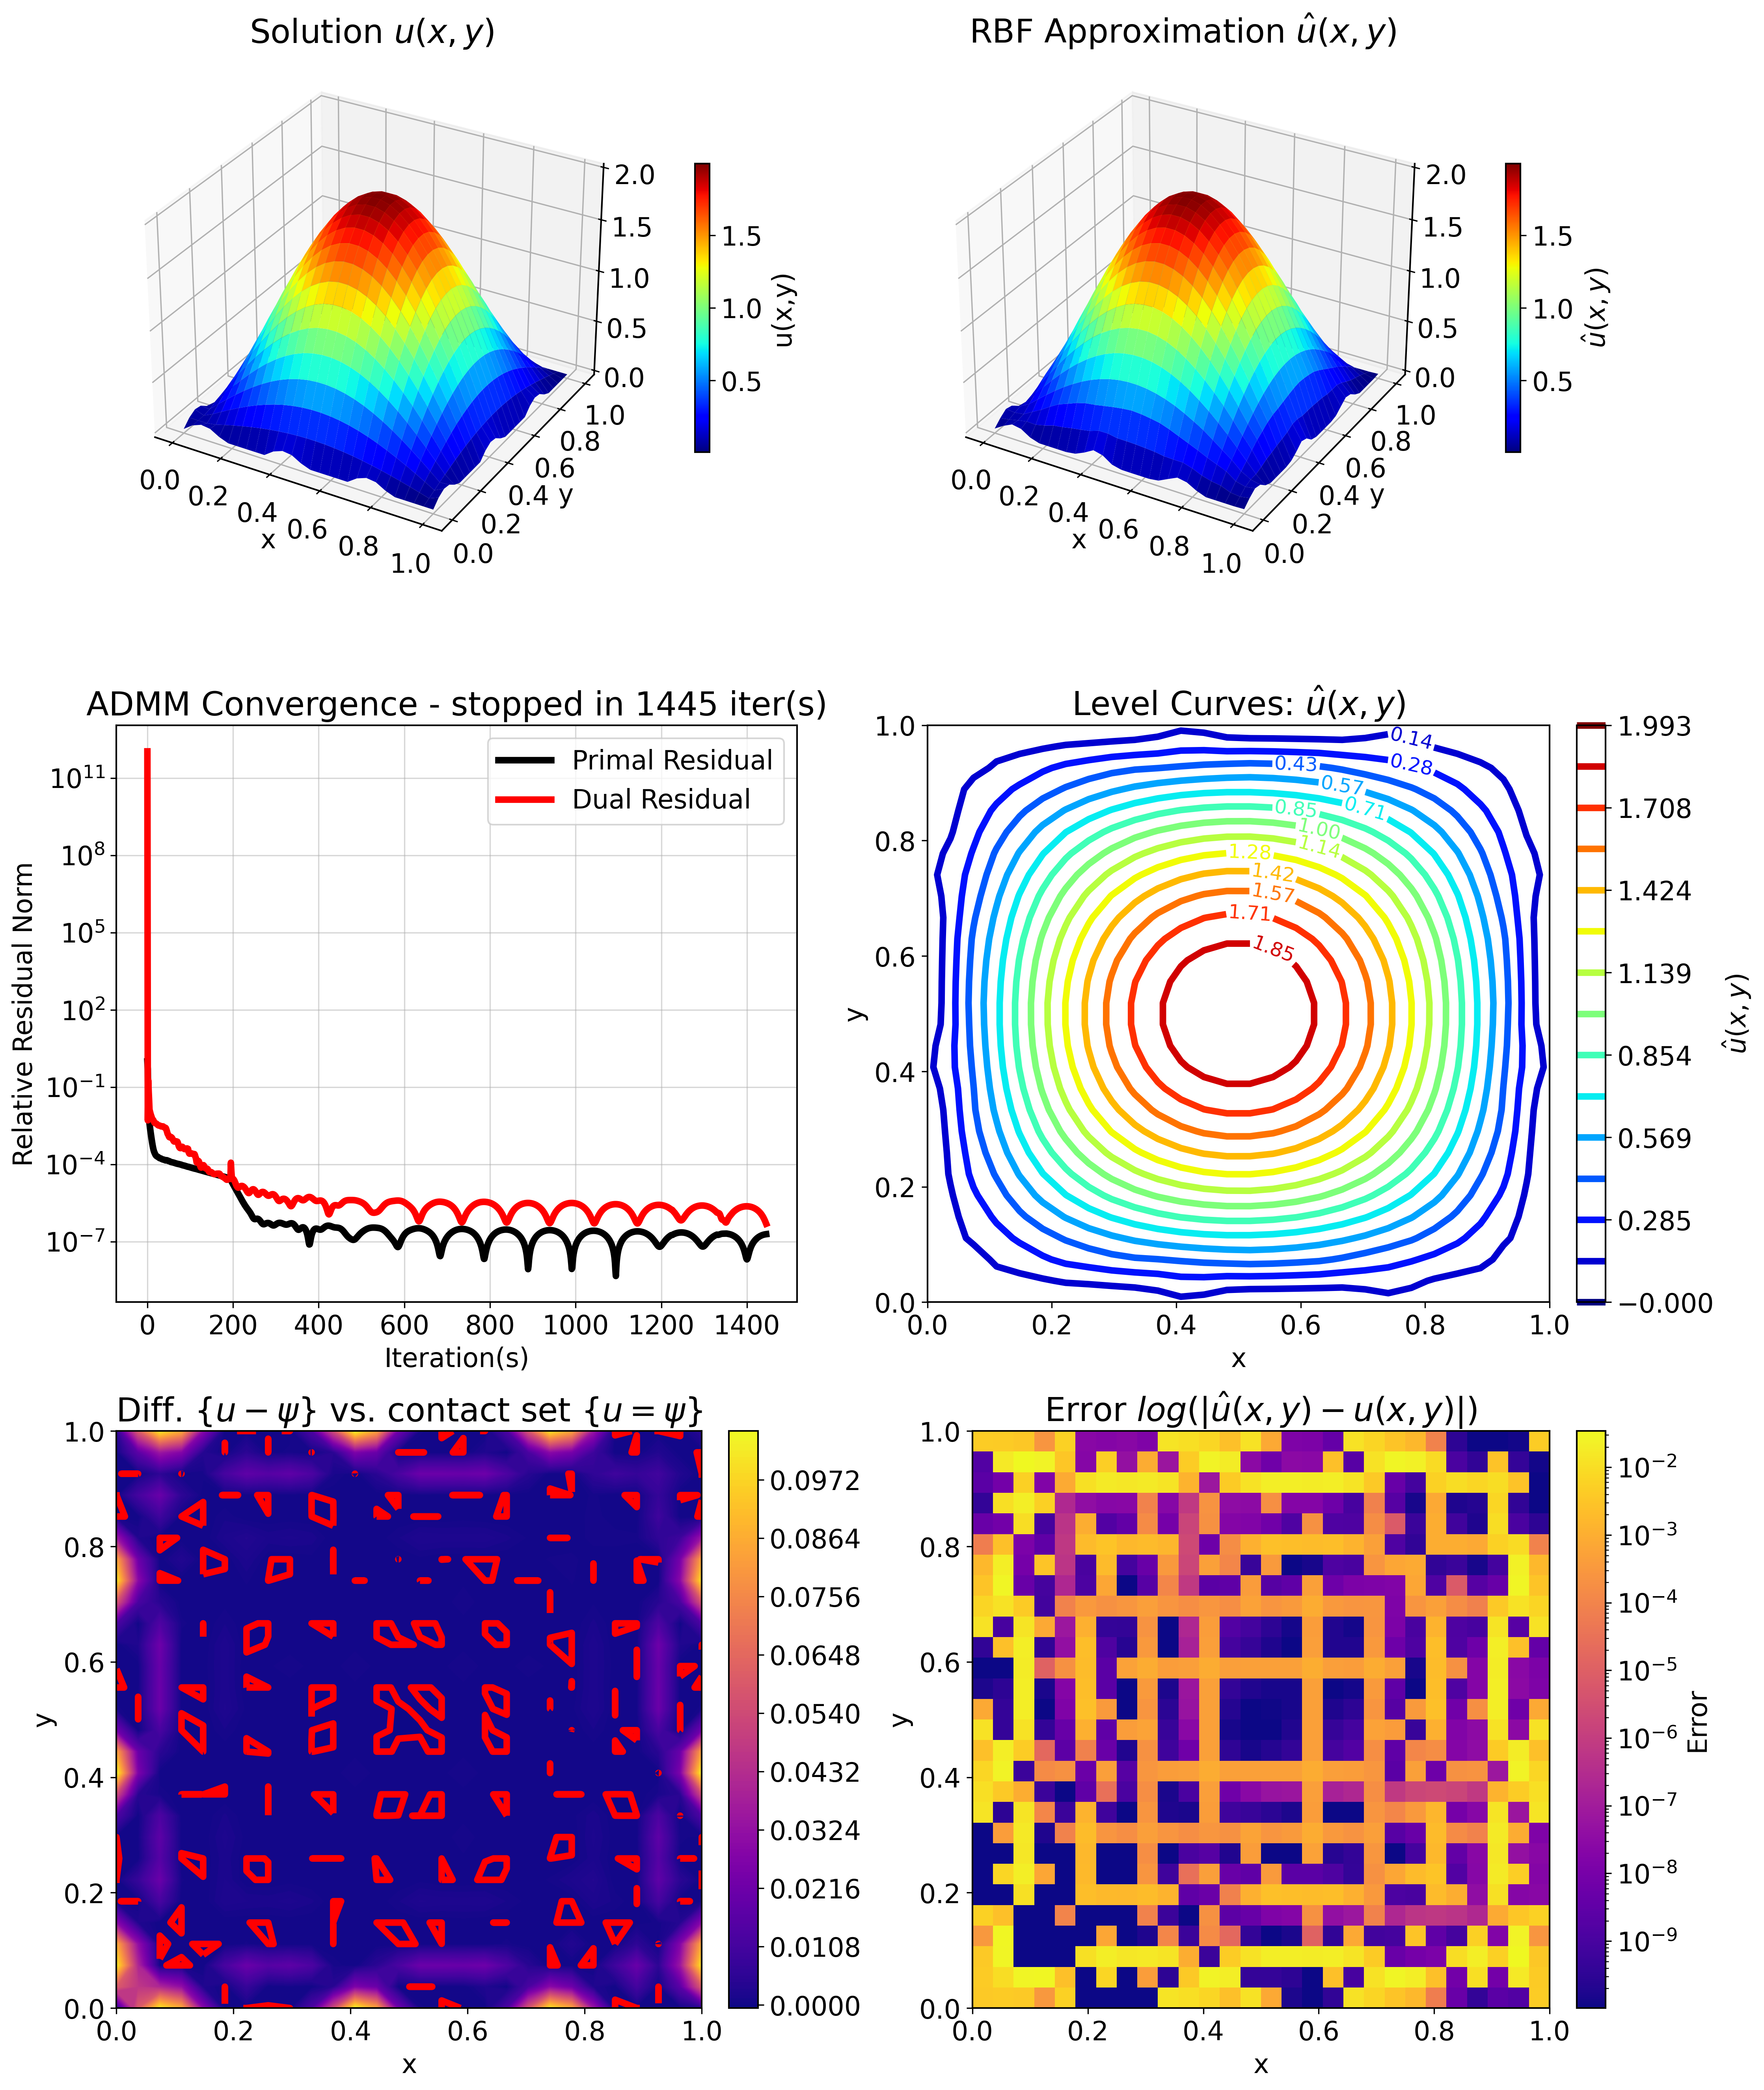

In [2]:
from google.colab import files


plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.5,
    'figure.dpi': 300,
})

print(f'Grid Size: m x m: {M}x{M}')
# -------------------------
# Relative error
# -------------------------
rel_err = norm(u_rbf - u_exact_vals)**2 / norm(u_exact_vals)**2
print(f"Relative L2 error (RBF vs Analytical): {rel_err:.2e}")

# -------------------------
# Plot
# -------------------------
fig = plt.figure(figsize=(15, 18))

# Row 1: 3D solutions
ax1 = fig.add_subplot(3, 2, 1, projection='3d')
surf = ax1.plot_surface(X, Y, U_exact, cmap='jet', edgecolor='none')
ax1.set_title('Solution $u(x,y)$')
# turn off the background grid lines
#ax1.grid(False)
ax1.set_xlabel('x'); ax1.set_ylabel('y');
#ax1.set_zlabel('u')
# add a colorbar for this surface
fig.colorbar(surf,
             ax=ax1,
             shrink=0.5,
             pad=0.1,
             label='u(x,y)')

ax2 = fig.add_subplot(3, 2, 2, projection='3d')
surf_2 = ax2.plot_surface(X, Y, U_rbf, cmap='jet', edgecolor='none')
ax2.set_title('RBF Approximation $\hat{u}(x,y)$')
# turn off the background grid lines
#ax2.grid(False)
ax2.set_xlabel('x'); ax2.set_ylabel('y');
#ax2.set_zlabel('$\hat{u}$')
# add a colorbar for this surface
fig.colorbar(surf_2,
             ax=ax2,
             shrink=0.5,
             pad=0.1,
             label='$\hat{u}(x,y)$')

# Row 2: Residual and error
ax3 = fig.add_subplot(3, 2, 3)
ax3.semilogy(primal_residuals, label='Primal Residual', color = 'black')
ax3.semilogy(dual_residuals, label='Dual Residual', color = 'red')
ax3.set_title(f'ADMM Convergence - stopped in {it:2d} iter(s)')
ax3.set_xlabel('Iteration(s)'); ax3.set_ylabel('Relative Residual Norm')
ax3.legend(); ax3.grid(True)

ax4 = fig.add_subplot(3, 2, 4)
levels = np.linspace(U_rbf.min(), U_rbf.max(), 15)
cs = ax4.contour(X, Y, U_rbf, levels=levels, cmap='jet')
ax4.clabel(cs, inline=True, fontsize=12, fmt="%.2f")   # optional labels on curves
ax4.set_title('Level Curves: $\hat{u}(x,y)$')
ax4.set_xlabel('x'); ax4.set_ylabel('y')
fig.colorbar(cs, ax=ax4, fraction=0.046, pad=0.04, label='$\hat{u}(x,y)$')



# Row 3: Contours
ax5 = fig.add_subplot(3, 2, 5)
diff = U_rbf - Psi
cf5 = ax5.contourf(X, Y, diff, levels=200, cmap='plasma')
ax5.contour(X, Y, diff, levels=[0], colors='red', linestyles='-')
ax5.set_title(r'Diff. $\{ u - \psi \}$ vs. contact set $\{u = \psi\}$')
ax5.set_xlabel('x'); ax5.set_ylabel('y')
fig.colorbar(cf5, ax=ax5, fraction=0.1, pad=0.04)

ax6 = fig.add_subplot(3, 2, 6)
im6 = ax6.imshow(abs_error, origin='lower', extent=[0, L, 0, L],
                 cmap='plasma', norm=LogNorm(vmin=abs_error.min()+1e-10, vmax=abs_error.max()))
ax6.set_title('Error $log(|\hat{u}(x,y) - u(x,y)|)$')
ax6.set_xlabel('x'); ax6.set_ylabel('y')
cbar6 = fig.colorbar(im6, ax=ax6, fraction=0.046, pad=0.04)
cbar6.set_label('Error')
cbar6.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"$10^{{{int(np.log10(x))}}}$"))



plt.tight_layout()
plt.savefig('fig1_obstacle_2D_smooth.png')
files.download('fig1_obstacle_2D_smooth.png')


# Benchmark in N

In [3]:
import numpy as np
import time
import tracemalloc
from numpy.linalg import svd, norm
from numba import njit

def solve_rbf_admm(N_side, T=2, mu=2.5e4, rho=1e5,
                   max_iter=20_000, tau=1e-15, tol=5e-7,
                   L=1.0, beta=3e5, A=0.1, k=6, c = 1/20):
    # start tracking
    tracemalloc.start()
    t0 = time.perf_counter()

    # setup sizes
    N = N_side**2
    M_side = int(np.sqrt(T * N))
    M = M_side**2
    b = c * N

    # build points
    x = np.linspace(0, L, M_side)
    X, Y = np.meshgrid(x, x)
    pts = np.column_stack((X.ravel(), Y.ravel()))
    cx = np.linspace(0, L, N_side)
    CY, CX = np.meshgrid(cx, cx)
    centers = np.column_stack((CX.ravel(), CY.ravel()))

    # obstacle and boundary funcs
    pi = np.pi
    sinh_kpi = np.sinh(k*pi)
    def psi(xy, height = 2.0): return height*np.sin(pi*xy[:,0])*np.sin(pi*xy[:,1])
    def H(xy):
        x_, y_ = xy[:,0], xy[:,1]
        tx = np.sin(k*pi*x_)*(np.sinh(k*pi*y_)+np.sinh(k*pi*(1-y_)))/sinh_kpi
        ty = np.sin(k*pi*y_)*(np.sinh(k*pi*x_)+np.sinh(k*pi*(1-x_)))/sinh_kpi
        return A*(tx+ty)
    def u_true(xy): return np.maximum(psi(xy), H(xy))
    def g_bc(xy):
        x_, y_ = xy[:,0], xy[:,1]
        g = np.zeros_like(x_)
        for mask, var in [((y_==0)|(y_==L), x_), ((x_==0)|(x_==L), y_)]:
            g[mask] = A*np.sin(k*pi*var[mask]/L)
        return g

    # fast RBF
    @njit
    def rbf_fast(xy, centers, b):
        M_, N_ = xy.shape[0], centers.shape[0]
        out = np.empty((M_, N_))
        for i in range(M_):
            for j in range(N_):
                dx = xy[i,0]-centers[j,0]; dy = xy[i,1]-centers[j,1]
                out[i,j] = np.exp(-b*b*(dx*dx+dy*dy))
        return out

    Phi = rbf_fast(pts, centers, b)/np.sqrt(N)
    dx = L/(M_side-1)
    A1 = dx*dx*(Phi.T@Phi)

    bc_mask = (pts[:,0]==0)|(pts[:,0]==L)|(pts[:,1]==0)|(pts[:,1]==L)
    Phi_bc = Phi[bc_mask]
    gb = g_bc(pts[bc_mask])

    # system matrix
    A_mat = A1 + beta*(Phi_bc.T@Phi_bc) + rho*(Phi.T@Phi)

    # precompute SVD
    U,S,VT = svd(A_mat, full_matrices=False)
    thresh = tau*S.max()
    Sinv = np.where(S>thresh, 1/S, 0)
    def solve_svd(rhs):
        return VT.T @ (Sinv*(U.T@rhs))

    # ADMM initialize
    w = np.zeros(N); v = Phi@w; z = np.zeros(M)
    psi_vals = psi(pts)

    for it in range(max_iter):
        rhs = rho*(Phi.T@(v-z)) + beta*(Phi_bc.T@gb)
        w_new = solve_svd(rhs)
        proj = Phi@w_new + z
        v_new = np.maximum(proj - mu*dx*dx/rho, psi_vals)
        z_new = z + (Phi@w_new - v_new)

        # check convergence
        if norm(Phi@w_new - v_new)<tol and norm(rho*(Phi.T@(v_new-v)))<tol:
            break
        w,v,z = w_new,v_new,z_new

    # compute error
    u_approx = (Phi@w).reshape(M_side, M_side)
    u_ex = u_true(pts).reshape(M_side, M_side)
    rel_err = norm(u_approx-u_ex)**2/norm(u_ex)**2

    # stop tracking
    comp_time = time.perf_counter()-t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory_usage = peak / 1024**2

    return N, M, rel_err, memory_usage, comp_time

In [4]:
# Define the list of N_side values you want to benchmark
N_sides = [2, 5, 10, 15, 20, 25, 30, 35]
c_vals = [1/10,1/10, 1/20, 1/20, 1/20, 1/50, 1/50, 1/70]

# Prepare an empty list to collect results
results = []

for (Ns, c_val) in zip(N_sides, c_vals):
    # Run the solver: returns (rel_error, memory_MB, time_sec, M_grid)
    N, m, err, mem, t= solve_rbf_admm(Ns, c = c_val)
    print(f'N: {N:2d} | Gridsize: (m x m) = ({m:2d} x {m:2d}) |RelL2Error: {err:.3e} | Memory Storage (MB): {mem:.3f} | Comp. Time (sec.): {t:.3f}')

    # Append a tuple (or dict) with all metrics
    results.append({
        'N':         N,
        'm_grid':    m,
        'rel_error': err,
        'memory_MB': mem,
        'comp_time':  t
    })



N:  4 | Gridsize: (m x m) = ( 4 x  4) |RelL2Error: 1.000e+00 | Memory Storage (MB): 1.558 | Comp. Time (sec.): 0.519
N: 25 | Gridsize: (m x m) = (49 x 49) |RelL2Error: 4.347e-04 | Memory Storage (MB): 1.460 | Comp. Time (sec.): 0.385
N: 100 | Gridsize: (m x m) = (196 x 196) |RelL2Error: 1.426e-04 | Memory Storage (MB): 1.901 | Comp. Time (sec.): 0.828
N: 225 | Gridsize: (m x m) = (441 x 441) |RelL2Error: 7.523e-05 | Memory Storage (MB): 3.529 | Comp. Time (sec.): 2.822
N: 400 | Gridsize: (m x m) = (784 x 784) |RelL2Error: 5.066e-05 | Memory Storage (MB): 9.113 | Comp. Time (sec.): 10.531
N: 625 | Gridsize: (m x m) = (1225 x 1225) |RelL2Error: 1.311e-05 | Memory Storage (MB): 19.950 | Comp. Time (sec.): 31.742
N: 900 | Gridsize: (m x m) = (1764 x 1764) |RelL2Error: 1.704e-05 | Memory Storage (MB): 39.599 | Comp. Time (sec.): 60.899
N: 1225 | Gridsize: (m x m) = (2401 x 2401) |RelL2Error: 1.284e-05 | Memory Storage (MB): 71.782 | Comp. Time (sec.): 149.879


Memory fit: MB = 1.222e-05·m^2 + 1.468e+00
Time fit: Time = 2.934e-02·N^1.035
Error fit: Error = 1.370e+00·N^-1.757 (O(N^-1.757))


/tmp/ipython-input-7-1084778674.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

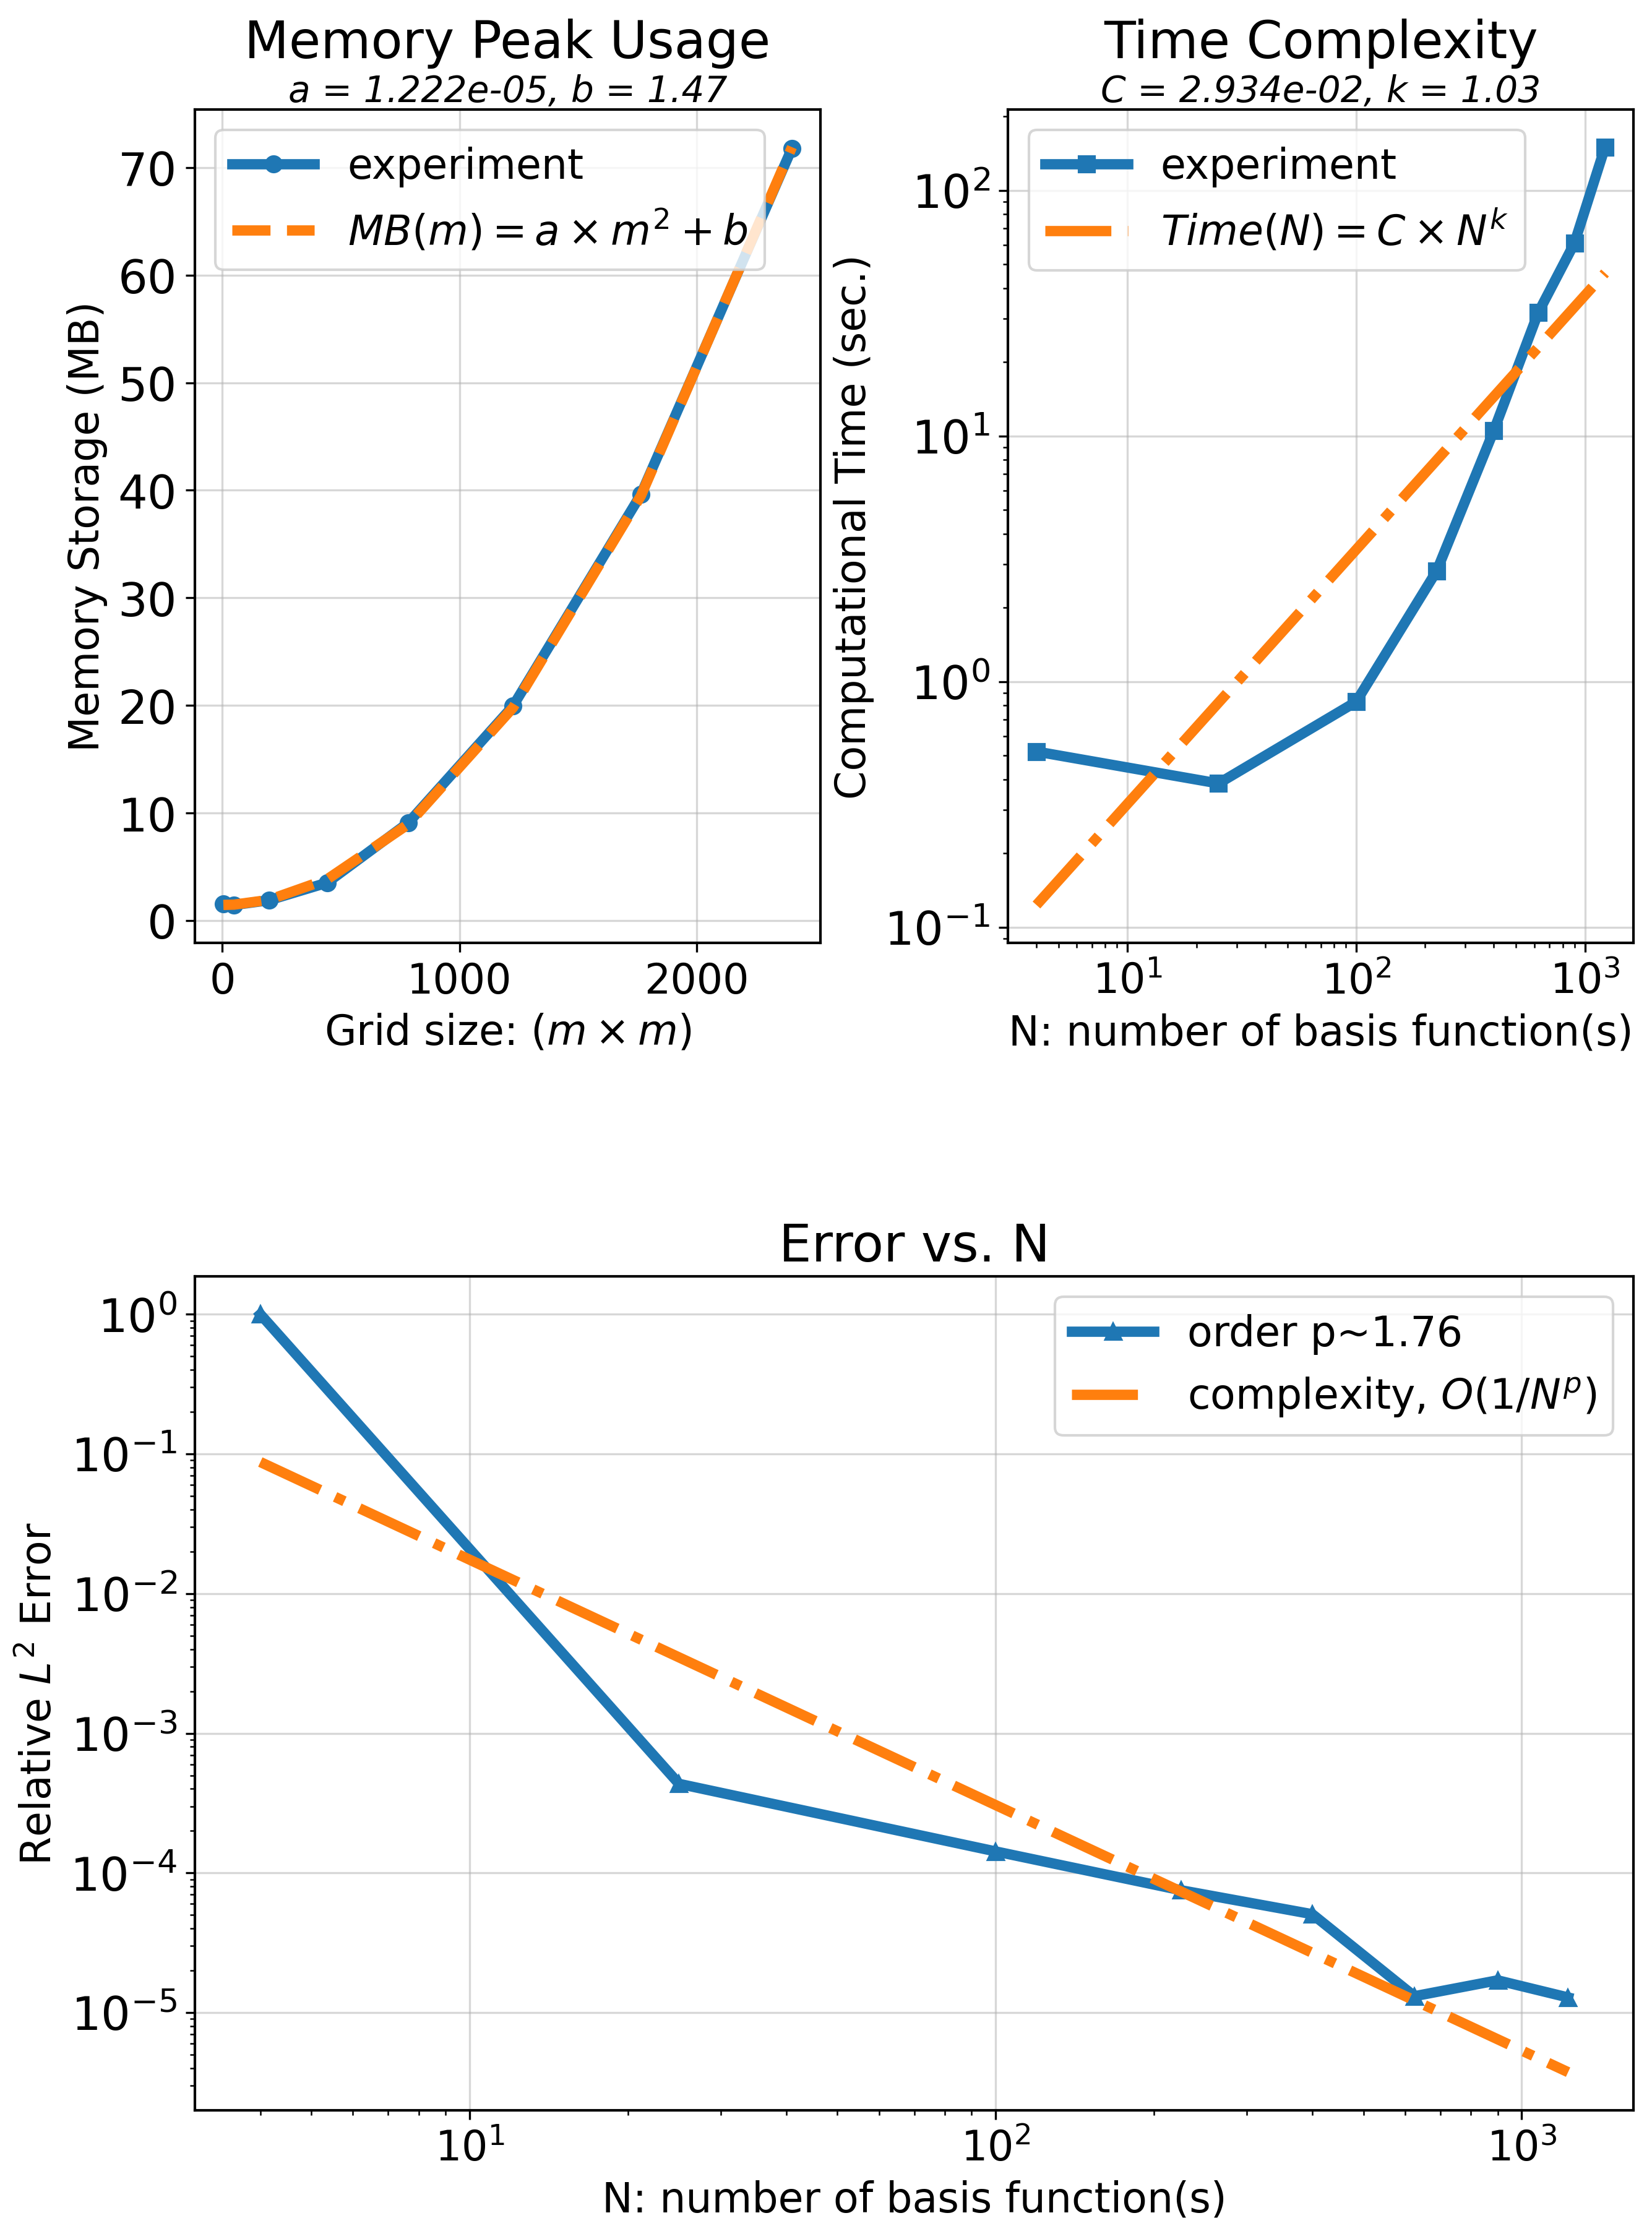

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import files
import numpy as np


plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 16,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.5,
    'figure.dpi': 300,
})


# Assuming `results` is a list of dicts with keys:
# 'N', 'M_grid', 'memory_MB', 'time_sec', 'rel_error'

# Extract data
m_vals      = np.array([r['m_grid']    for r in results])
memory_vals = np.array([r['memory_MB'] for r in results])
N_vals      = np.array([r['N']         for r in results])
time_vals   = np.array([r['comp_time']  for r in results])
error_vals  = np.array([r['rel_error'] for r in results])



# 1. Memory ~ a * M^2 + b
X1 = np.vstack([m_vals**2, np.ones_like(m_vals)]).T
a, b = np.linalg.lstsq(X1, memory_vals, rcond=None)[0]
print(f"Memory fit: MB = {a:.3e}·m^2 + {b:.3e}")

# 2. Time ~ C * N^k (log–log fit)
lnN, lnt = np.log(N_vals), np.log(time_vals)
k, lnC = np.polyfit(lnN, lnt, 1)
C = np.exp(lnC)
print(f"Time fit: Time = {C:.3e}·N^{k:.3f}")

# 3. Error ~ D * N^p (order of convergence)
lnErr = np.log(error_vals)
p, lnD = np.polyfit(lnN, lnErr, 1)
D = np.exp(lnD)
print(f"Error fit: Error = {D:.3e}·N^{p:.3f} (O(N^{p:.3f}))")



# Create figure and gridspec
fig = plt.figure(figsize=(10, 14))
gs  = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.4, wspace=0.3)

# Top-left: Memory vs Grid Size
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(m_vals, memory_vals, 'o-', linewidth=4, color = 'tab:blue', label = 'experiment')
ax1.plot(m_vals, a * m_vals**2 + b, '--', linewidth=4, color = 'tab:orange', label = f'$MB(m) = a \\times m^2 + b$')
ax1.legend(frameon = True)
ax1.set_xlabel(f'Grid size: $(m \\times m)$')
ax1.set_ylabel('Memory Storage (MB)')
ax1.set_title('Memory Peak Usage', pad = 20)
ax1.text(
    0.5, 1.0,
    f'a = {a:.3e}, b = {b:.2f}',
    transform=ax1.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontstyle="italic"
)

ax1.grid(True)

# Top-right: Time Complexity (log-log)
ax2 = fig.add_subplot(gs[0, 1])
ax2.loglog(N_vals, time_vals, 's-', linewidth=4, label = 'experiment', color = 'tab:blue')
ax2.loglog(N_vals, C * N_vals**k, '-.', linewidth=4, label = f'$Time(N) = C \\times N^k$', color = 'tab:orange')
ax2.legend(frameon = True)
ax2.set_xlabel('N: number of basis function(s)')
ax2.set_ylabel('Computational Time (sec.)')
ax2.set_title('Time Complexity', pad = 20)
ax2.text(
    0.5, 1.0,
    f'C = {C:.3e}, k = {k:.2f}',
    transform=ax2.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontstyle="italic"
)
ax2.grid(True)

# Bottom (spanning both): Error vs Problem Size (log-log)
ax3 = fig.add_subplot(gs[1, :])
ax3.loglog(N_vals, error_vals, '^-', linewidth=4, label = f'order p~{-p:.2f}')
ax3.loglog(N_vals, N_vals**p, '-.', label = f'complexity, $O(1/N^p)$')
ax3.legend(frameon = True)
ax3.set_xlabel('N: number of basis function(s)')
ax3.set_ylabel(f'Relative $L^2$ Error')
ax3.set_title('Error vs. N')
ax3.grid(True)

plt.tight_layout()
plt.savefig('fig2_obstacle_2D_smooth.png')
files.download('fig2_obstacle_2D_smooth.png')